# From Reviewed Parser Output to Campus Exclusions Documentation

This notebook covers the reviewed publication workflow that follows the automated Alma Analytics catalog parser. It validates the manually enriched normalized workbook, previews the campus publications, and can run the campus documentation exporter when publication is explicitly enabled.

## Workflow boundary

The parser and publication workflows are intentionally separate. The parser creates review-ready rule tables; staff then make judgments that cannot always be inferred safely from the source XML.

Input:

- `output/normalized_combined_saved_column_and_filter_review.xlsx`
- `output/saved_column_review.csv`, used to refresh parser-derived criterion text before publication

The normalized workbook combines filter and saved-column rules and adds human-maintained information:

- Electronic, Physical, or Fulfillment domain
- campus or global scope
- review labels and explanations
- campus-specific rule selection

Outputs:

- one campus exclusions-documentation workbook for each worksheet whose name begins with `UC`
- files written under `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/`
- canonical names such as `UCB_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`

## Report-builder pipeline map


This diagram shows how the saved-column and filter review exports move through manual normalization and into the campus documentation exporter. Solid arrows identify required data dependencies; the dashed arrow identifies the optional notebook-controlled validation and execution path. The audit-only filter-criteria export is shown for context but is not an input to the report builder.

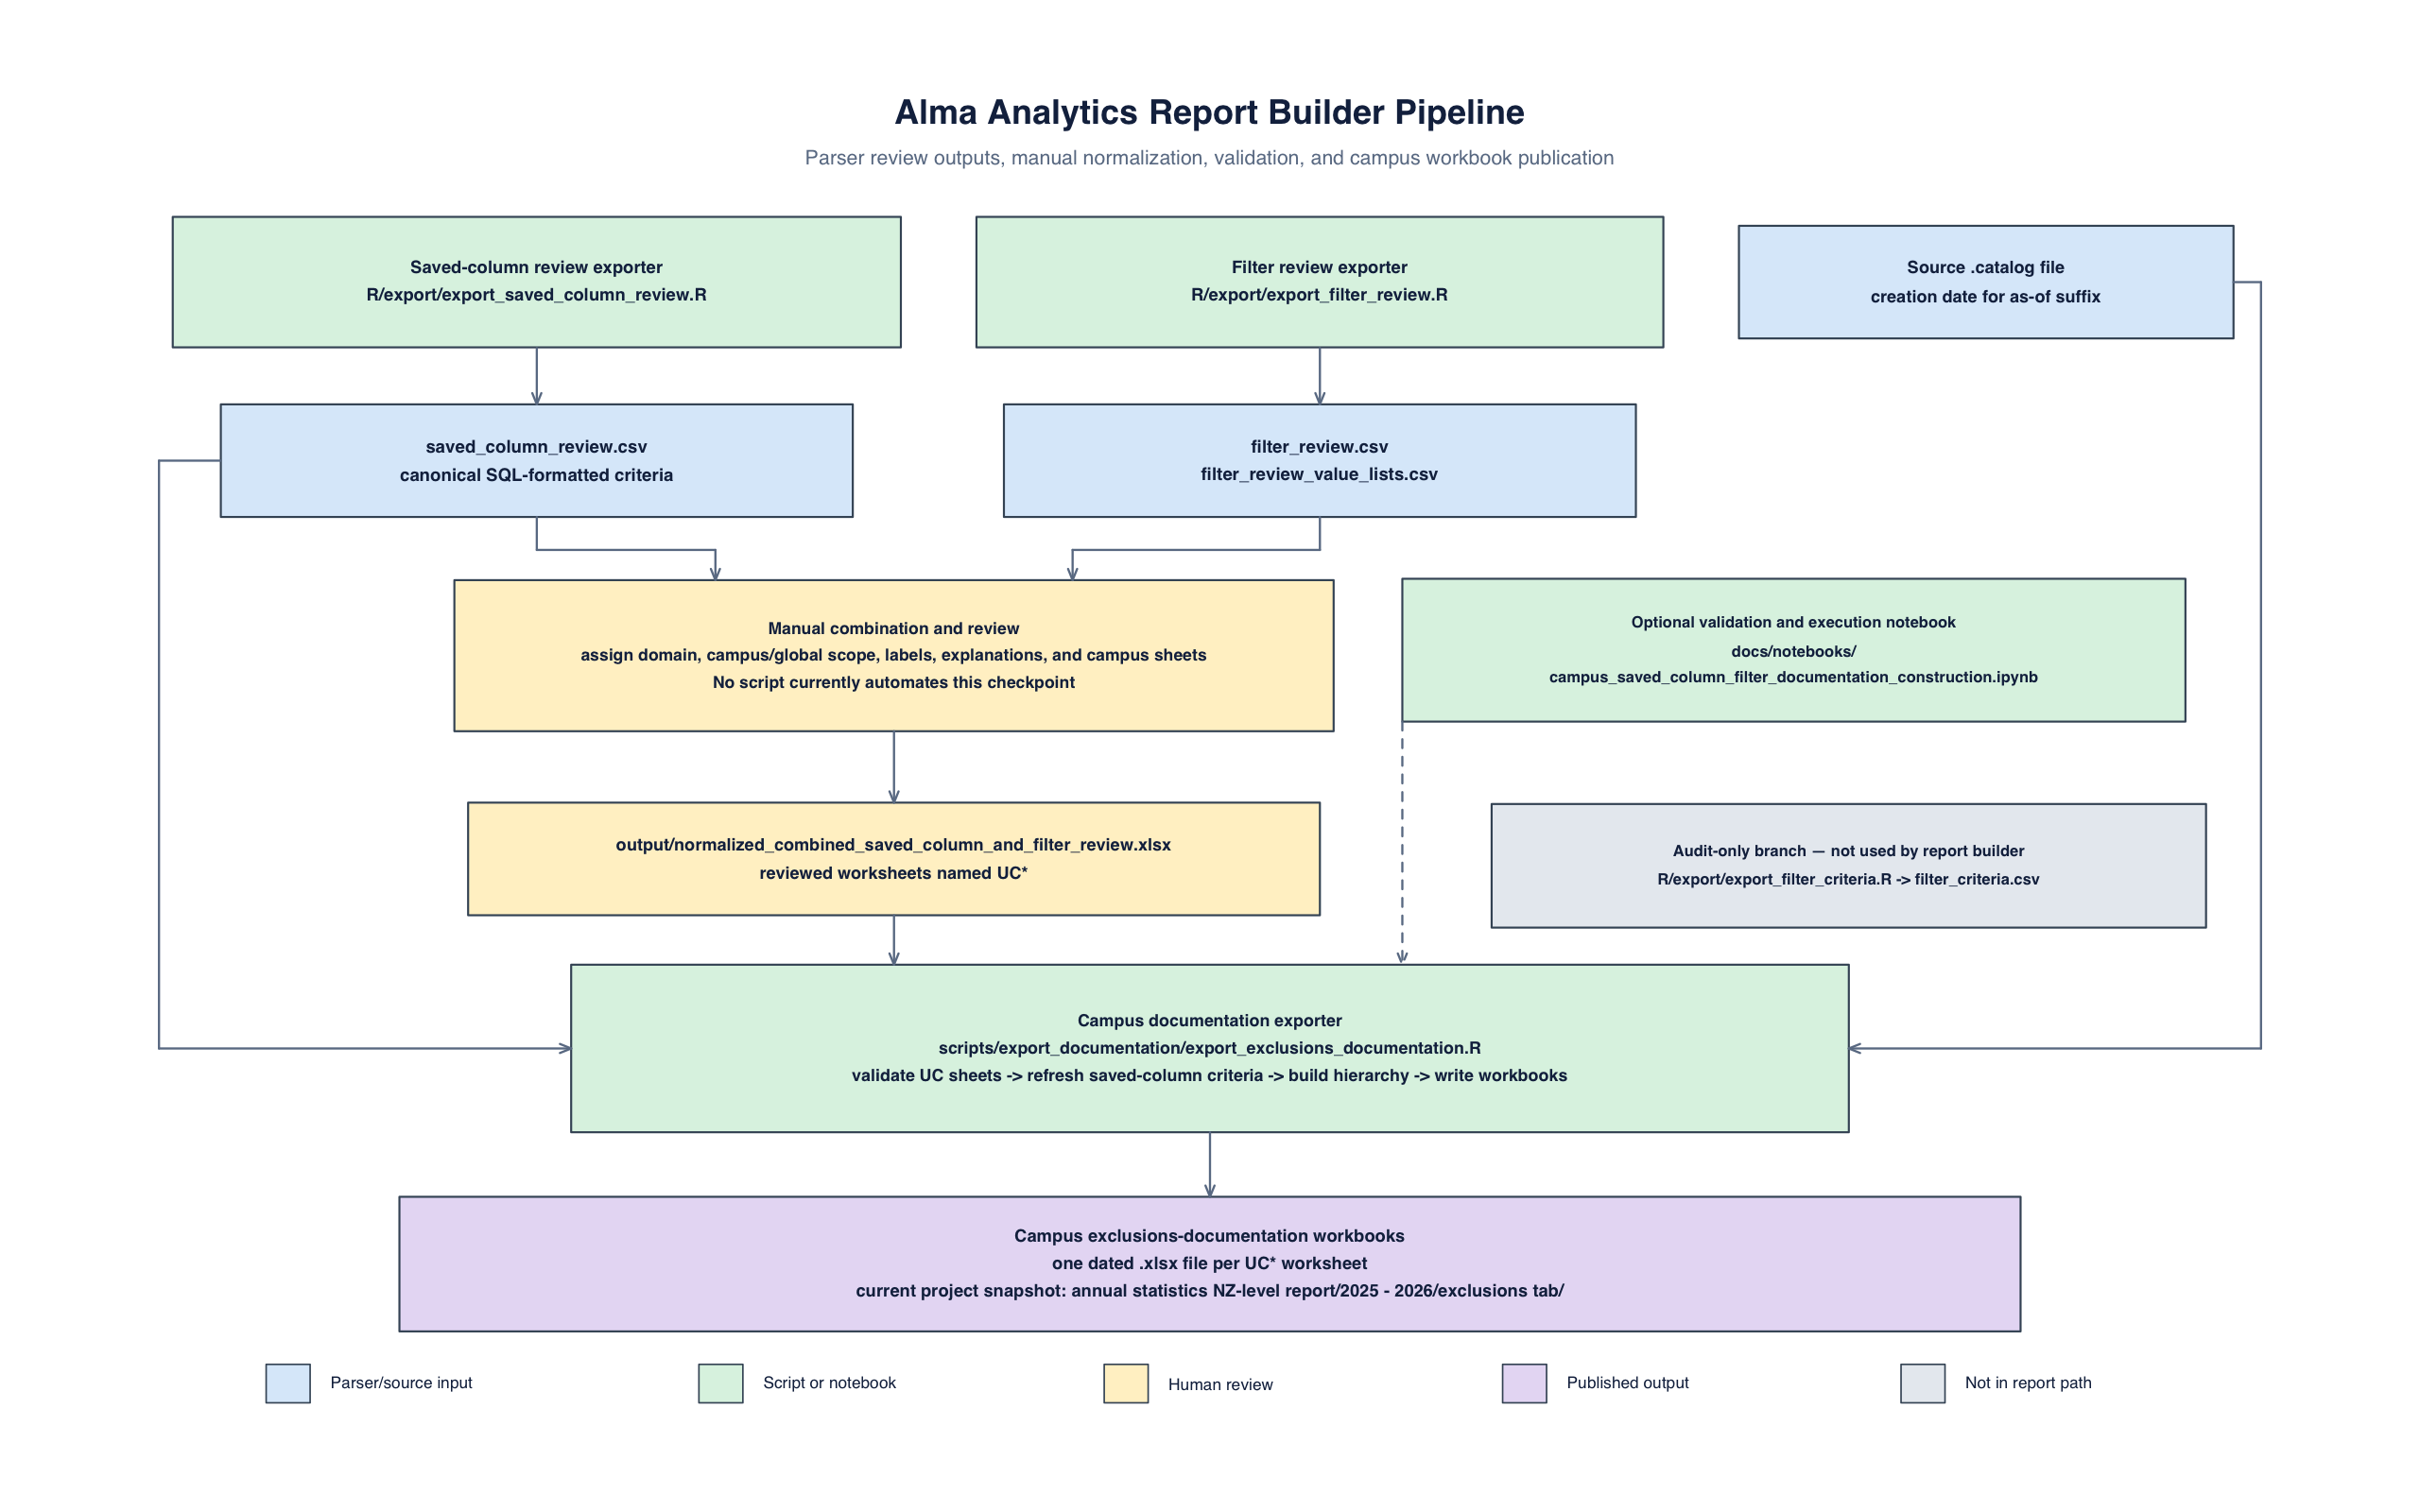

In [ ]:
source("scripts/render_report_builder_pipeline_diagram.R")

report_builder_diagram_path <- render_report_builder_pipeline_diagram(
  "documentation/images/run_report_builder_pipeline_diagram.png"
)

if (!requireNamespace("IRdisplay", quietly = TRUE)) {
  stop("IRdisplay is required to show the diagram in this notebook.")
}
IRdisplay::display_png(file = report_builder_diagram_path)


## Before running

1. Open the notebook from the repository root with an R kernel.
2. Confirm that the normalized workbook has completed human review.
3. Run the validation and preview cells.
4. Inspect the proposed campus files.
5. Set `publish_campus_workbooks` to `TRUE` only when the files are ready to be written.

The workflow requires the R packages `readxl` and `openxlsx2`. Existing files with the same canonical names are overwritten during publication.

## Configure the publication

In [ ]:
normalized_review_path <- file.path(
  "output",
  "normalized_combined_saved_column_and_filter_review.xlsx"
)
saved_column_review_path <- file.path("output", "saved_column_review.csv")
catalog_path <- file.path(
  "data",
  "examples",
  "annual_stats_fy_2025_2026.catalog"
)
fiscal_year <- "FY 2025-26"
documentation_output_dir <- file.path(
  "output",
  paste("Campus", fiscal_year, "annual statistics NZ-level output"),
  "2025",
  "2026"
)
publication_script <- file.path(
  "scripts",
  "export_documentation",
  "export_exclusions_documentation.R"
)
publish_campus_workbooks <- FALSE

## Validate the normalized workbook

This check stops before publication if the workbook, exporter, packages, campus worksheets, or required columns are missing. It also reports the number of source records on each campus worksheet.

In [ ]:
required_packages <- c("readxl", "openxlsx2")
missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]
if (length(missing_packages) > 0L) {
  stop(
    "Install the required R package(s): ",
    paste(missing_packages, collapse = ", ")
  )
}
if (!file.exists(normalized_review_path)) {
  stop("Normalized review workbook not found: ", normalized_review_path)
}
if (!file.exists(saved_column_review_path)) {
  stop("Canonical saved-column review not found: ", saved_column_review_path)
}
if (!file.exists(catalog_path)) {
  stop("Source .catalog file not found: ", catalog_path)
}
if (!file.exists(publication_script)) {
  stop("Publication script not found: ", publication_script)
}

expected_columns <- c(
  "rule_type",
  "source_workbook",
  "Electronic/Physical/Fulfillment",
  "Campus",
  "rule_name",
  "rule_id",
  "join_operator",
  "criterion_text",
  "value_count",
  "review_label",
  "explanation",
  "criterion_text_category"
)

workbook_sheets <- readxl::excel_sheets(normalized_review_path)
campus_sheets <- workbook_sheets[grepl("^UC[A-Z]+$", workbook_sheets)]
if (length(campus_sheets) == 0L) {
  stop("No campus worksheets found; expected names such as UCB or UCLA.")
}

campus_validation <- do.call(
  rbind,
  lapply(campus_sheets, function(campus) {
    campus_data <- readxl::read_excel(
      normalized_review_path,
      sheet = campus,
      .name_repair = "minimal"
    )
    missing_columns <- setdiff(expected_columns, names(campus_data))
    data.frame(
      campus = campus,
      source_records = nrow(campus_data),
      missing_columns = paste(missing_columns, collapse = ", "),
      valid = length(missing_columns) == 0L,
      stringsAsFactors = FALSE
    )
  })
)

if (!all(campus_validation$valid)) {
  invalid <- campus_validation[!campus_validation$valid, , drop = FALSE]
  stop(
    "Campus worksheet validation failed: ",
    paste(
      paste0(invalid$campus, " missing " , invalid$missing_columns),
      collapse = "; "
    )
  )
}

campus_validation

## Preview the documentation outputs

The canonical filename keeps the campus, workflow, fiscal year, and document purpose visible without temporary status or publication-date prefixes. Publication dates should be recorded in workbook metadata or version history instead.

For the current normalized workbook, the proposed outputs are:

- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCB_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCD_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCI_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCLA_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCM_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCR_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCSB_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCSC_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCSD_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`
- `output/Campus FY 2025-26 annual statistics NZ-level output/2025/2026/UCSF_targeted_review_FY2025-26_exclusions_documentation_as_of_2026-07-09.xlsx`

The code cell below derives the list from the workbook sheet names so it will reveal any future campus additions or removals.

In [ ]:
fiscal_year_filename <- gsub("[[:space:]]+", "", fiscal_year)
catalog_as_of_date <- format(
  as.Date(file.info(catalog_path)$mtime[[1L]]),
  "%Y-%m-%d"
)
proposed_output_files <- file.path(
  documentation_output_dir,
  paste0(
    campus_sheets,
    "_targeted_review_",
    fiscal_year_filename,
    "_exclusions_documentation_as_of_",
    catalog_as_of_date,
    ".xlsx"
  )
)

cat(paste0("- `", proposed_output_files, "`", collapse = "\n"))

## Publish the campus workbooks

The safety flag defaults to `FALSE`. Change it only after reviewing the validation table and proposed output list. The exporter organizes each workbook as:

`Domain → Campus/global scope → Filter or saved column → Rule name → Individual criterion`

In [ ]:
if (isTRUE(publish_campus_workbooks)) {
  publication_status <- system2(
    "Rscript",
    c(
      publication_script,
      normalized_review_path,
      documentation_output_dir,
      catalog_path
    )
  )
  if (!identical(publication_status, 0L)) {
    stop("Campus documentation publication failed.")
  }
} else {
  message("Publication skipped. Set publish_campus_workbooks <- TRUE when ready.")
}

## List the published documentation

This final check lists the campus documentation currently present in the output directory as bullet points. After publication, compare it with the proposed list above.

In [ ]:
published_files <- if (dir.exists(documentation_output_dir)) {
  list.files(
    documentation_output_dir,
    pattern = "\\.xlsx$",
    full.names = TRUE
    )
} else {
  character()
}

if (length(published_files) == 0L) {
  cat("- No published campus documentation workbooks found.")
} else {
  cat(paste0("- `", sort(published_files), "`", collapse = "\n"))
}

## Publication notes

- The normalized workbook remains the reviewed source of truth for campus selection and explanatory fields.
- `scripts/export_documentation/export_exclusions_documentation.R` currently labels workbooks FY 2025–26; update both the script and this notebook for a new annual cycle.
- The exporter overwrites only files that match the proposed canonical campus filenames.
- The parser does not create the normalized workbook automatically, so the human-review checkpoint remains explicit.
- Automated tests do not yet cover normalized-workbook transformations or campus publication.